## Part 2: Simple Text Processing - Tokenization, Lemmatization, Word Frequency, Vectorization (20 pts)

Now we will start working on simple text processing using the `SpaCy` package and the same dataset as Part 1. The package should already be included in the `environment.yml`. However, we will also need to download `en_core_web_sm`, an English language text processing model. To do this, while having your `sotu` environment activated, run the following:

```
python -m spacy download en_core_web_sm
```

Now, you should be good to go!

Some important definitions:

- *Token*: a single word or piece of a word
- *Lemma*: the core component of a word, e.g., "complete" is the lemma for "completed" and "completely"
- *Stop Word*: a common word that does not add semantic value, such as "a", "and", "the", etc.
- *Vectorization*: representing a document as a vector where each index in the vector corresponds to a token or word and each entry is the count.

In this section, we will explore the most common tokens and lemmas throughout different slices of the speech data. We will also develop vectorization representations of the speeches. 

 The core steps are:

1. Process speeches using the SpaCy nlp module
2. Analyze Tokens vs Lemmas:
- Create a list of all tokens across all speeches that are not stop words, punctuation, or spaces.
- Create a second list of the lemmas for these same tokens.
- Display the top 25 for each of these and compare.
3. Analyze common word distributions over different years:
- Create a function that takes the dataset and a year as an input and outputs the top n lemmas for that year's speeches
- Compare the top 10 words for 2023 versus 2019
4. Document Vectorization:
- Train a Term Frequency-Inverse Document Frequency (TF-IDF) vectorization model using your processed dataset and scikit learn
- Output the feature vectors 

**Helpful Resources:**
- https://realpython.com/natural-language-processing-spacy-python/
- https://www.statology.org/text-preprocessing-feature-engineering-spacy/ 
- https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html# 
- https://www.geeksforgeeks.org/nlp/how-to-store-a-tfidfvectorizer-for-future-use-in-scikit-learn/ 


### Step 1: Process speeches using the SpaCy nlp module

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from tqdm import tqdm
from collections import Counter
from sklearn.decomposition import PCA
from matplotlib.colors import LogNorm

nlp = spacy.load("en_core_web_sm")

In [61]:
sou = pd.read_csv("data/SOTU.csv")
sou_21cen = sou[sou["Year"] >= 2000].reset_index(drop=True)
sou_21cen

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
5,Donald J. Trump,2019.0,"\nThe President. Madam Speaker, Mr. Vice Presi...",5519
6,Donald J. Trump,2018.0,"\nThe President. Mr. Speaker, Mr. Vice Preside...",5755
7,Donald J. Trump,2017.0,"\nThank you very much. Mr. Speaker, Mr. Vice P...",4903
8,Barack Obama,2016.0,"\nThank you. Mr. Speaker, Mr. Vice President, ...",5956
9,Barack Obama,2015.0,"\nThe President. Mr. Speaker, Mr. Vice Preside...",6659


### Step 2: Analyze Tokens vs Lemmas

In [62]:
processed_speech = []

for text in tqdm(sou_21cen["Text"], desc="Processing"):
    doc = nlp(text)
    processed_speech.append(doc)

Processing: 100%|██████████| 25/25 [00:23<00:00,  1.07it/s]


In [63]:
tokens = []

for doc in processed_speech:
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens.append(token.text.lower())

token_counts = Counter(tokens)
top_tokens = token_counts.most_common(25)
top_tokens

[('america', 816),
 ('people', 637),
 ('american', 582),
 ('new', 530),
 ('years', 439),
 ('americans', 437),
 ('world', 425),
 ('year', 406),
 ('country', 369),
 ('jobs', 348),
 ('tonight', 344),
 ('work', 324),
 ('know', 323),
 ('let', 320),
 ('congress', 317),
 ('nation', 311),
 ('time', 301),
 ('help', 282),
 ('need', 266),
 ('tax', 255),
 ('president', 247),
 ('economy', 243),
 ('like', 241),
 ('right', 240),
 ('want', 237)]

In [64]:
lemmas = []

for doc in processed_speech:
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space:
            lemmas.append(token.lemma_.lower())

lemma_counts = Counter(lemmas)
top_lemmas = lemma_counts.most_common(25)
top_lemmas

[('year', 845),
 ('america', 816),
 ('people', 639),
 ('american', 587),
 ('work', 557),
 ('new', 532),
 ('job', 486),
 ('country', 435),
 ('americans', 432),
 ('world', 426),
 ('know', 395),
 ('nation', 388),
 ('help', 378),
 ('need', 353),
 ('time', 351),
 ('tonight', 344),
 ('child', 332),
 ('let', 326),
 ('congress', 317),
 ('come', 301),
 ('family', 296),
 ('good', 294),
 ('right', 282),
 ('million', 274),
 ('want', 264)]

In [65]:
tokens_w, tokens_c = zip(*top_tokens)
lemmas_w, lemmas_c = zip(*top_lemmas)

compare_df = pd.DataFrame({
    "Token": tokens_w,
    "Token Count": tokens_c,
    "Lemma": lemmas_w,
    "Lemma Count": lemmas_c
})
compare_df

,Token,Token Count,Lemma,Lemma Count
0,america,816,year,845
1,people,637,america,816
2,american,582,people,639
3,new,530,american,587
4,years,439,work,557
5,americans,437,new,532
6,world,425,job,486
7,year,406,country,435
8,country,369,americans,432
9,jobs,348,world,426


In the token list, words like “year” and “years” appear separately, so their counts are split across two entries (439 for years and 406 for year). After lemmatization, these are merged into the single lemma “year”, which now shows a higher combined count of 845, giving a clearer picture of how often this concept appears. A similar pattern shows up for “job/jobs”. In the token table, jobs appears with a count of 348, but once we normalize to the lemma “job”, the total frequency rises to 486. These examples illustrates how lemmas group different grammatical forms together, revealing the underlying themes more clearly than raw tokens.

### Step 3: Analyze common word distributions over different years:

In [66]:
def top_lemmas_by_year(df, year, n=10):
    docs = nlp.pipe(df[df["Year"] == year]["Text"])
    lemmas = [
        token.lemma_.lower()
        for doc in docs
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return Counter(lemmas).most_common(n)

In [67]:
top_2024 = top_lemmas_by_year(sou_21cen, 2024, 10)
top_2024

[('president', 58),
 ('year', 45),
 ('america', 44),
 ('american', 34),
 ('people', 33),
 ('$', 33),
 ('member', 32),
 ('want', 29),
 ('audience', 29),
 ('know', 29)]

In [68]:
top_2023 = top_lemmas_by_year(sou_21cen, 2023, 20)
top_2017 = top_lemmas_by_year(sou_21cen, 2017, 20)

In [69]:
top_2023

[('year', 58),
 ('go', 56),
 ('let', 45),
 ('know', 40),
 ('people', 39),
 ('job', 38),
 ('america', 36),
 ('come', 33),
 ('law', 33),
 ('pay', 33),
 ('american', 31),
 ('$', 31),
 ('president', 30),
 ('look', 27),
 ('world', 25),
 ('folk', 24),
 ('nation', 24),
 ('audience', 23),
 ('work', 23),
 ('right', 23)]

In [70]:
top_2017

[('american', 34),
 ('america', 29),
 ('country', 26),
 ('nation', 21),
 ('great', 20),
 ('new', 19),
 ('year', 19),
 ('world', 18),
 ('job', 15),
 ('people', 15),
 ('americans', 14),
 ('united', 13),
 ('tonight', 13),
 ('states', 12),
 ('work', 12),
 ('child', 12),
 ('want', 12),
 ('time', 12),
 ('citizen', 11),
 ('right', 11)]

In [71]:
lem23, cnt23 = zip(*top_2023)
lem17, cnt17 = zip(*top_2017)

compare_2017_2023_df = pd.DataFrame({
    "2023 Lemma": lem23,
    "2023 Count": cnt23,
    "2017 Lemma": lem17,
    "2017 Count": cnt17
})
compare_2017_2023_df

,2023 Lemma,2023 Count,2017 Lemma,2017 Count
0,year,58,american,34
1,go,56,america,29
2,let,45,country,26
3,know,40,nation,21
4,people,39,great,20
5,job,38,new,19
6,america,36,year,19
7,come,33,world,18
8,law,33,job,15
9,pay,33,people,15


We see 2023 uses more economy-focused language (e.g., job, pay), whereas 2017 emphasizes national identity (american, states, united).

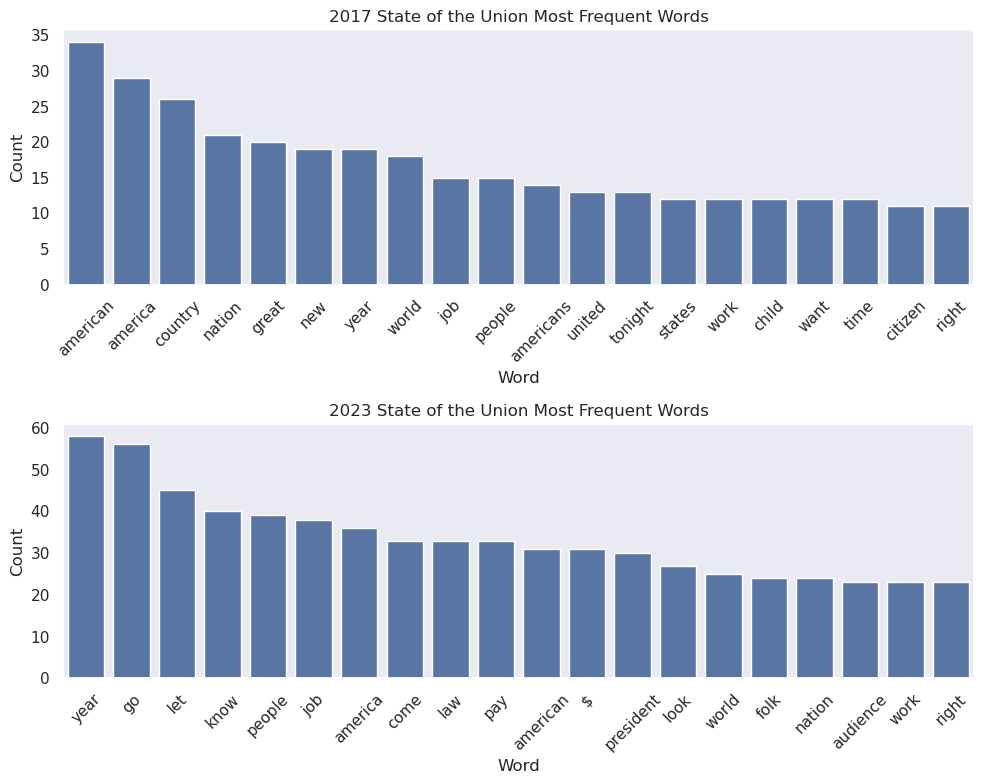

In [72]:
sns.set_theme(style="dark")
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sns.barplot(
    ax=axes[0],
    x="2017 Lemma",
    y="2017 Count",
    data=compare_2017_2023_df
)
axes[0].set_title("2017 State of the Union Most Frequent Words")
axes[0].set_xlabel("Word")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


sns.barplot(
    ax=axes[1],
    x="2023 Lemma",
    y="2023 Count",
    data=compare_2017_2023_df,
)
axes[1].set_title("2023 State of the Union Most Frequent Words")
axes[1].set_xlabel("Word")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Step 4: Document Vectorization

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Convert speech text column into a list of documents
raw_docs = sou["Text"].to_list()
# Create and fit the TF-IDF vectorizer on the speeches
tfidf_model = TfidfVectorizer()
tfidf_vectors = tfidf_model.fit_transform(raw_documents=raw_docs)
# Get the list of vocabulary words learned by TF-IDF
feature_names = tfidf_model.get_feature_names_out()
tfidf_dense = tfidf_vectors.toarray()
# Turn the TF-IDF results into a DataFrame
tfidf_df = pd.DataFrame(
    tfidf_dense,
    columns=feature_names,
    index=sou["Year"]   
)
tfidf_df


,00,000,0000,0001,000m,000page,001,002,003,004,...,zimbabwean,zinc,zion,zollverein,zone,zones,zoological,zooming,zuloaga,ôtil
Year,,,,,,,,,,,,,,,,,,,,,
2024.0,0.0,0.021959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2023.0,0.0,0.027715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2022.0,0.0,0.016401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2021.0,0.0,0.015540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.008169,0.000000,0.0,0.0,0.0,0.0
2020.0,0.0,0.034205,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.017812,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1791.0,0.0,0.018668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1790.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1790.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [104]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tfidf_df)
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"],
    index=tfidf_df.index  
)
pca_df

,PC1,PC2
Year,,
2024.0,-0.285380,-0.255487
2023.0,-0.353750,-0.250746
2022.0,-0.378739,-0.209739
2021.0,-0.334333,-0.180414
2020.0,-0.306456,-0.074874
...,...,...
1791.0,0.203833,-0.066724
1790.0,0.106423,-0.109900
1790.0,0.106423,-0.109900


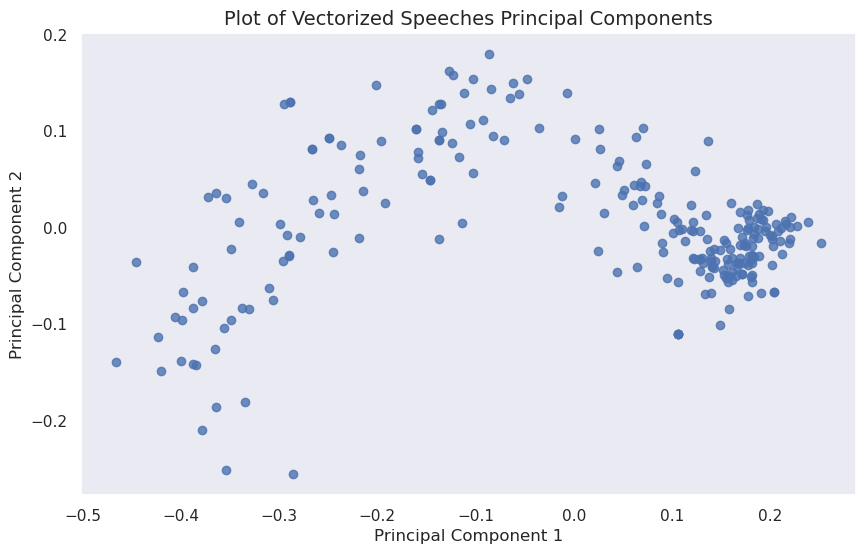

In [105]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.8)

plt.title("Plot of Vectorized Speeches Principal Components", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

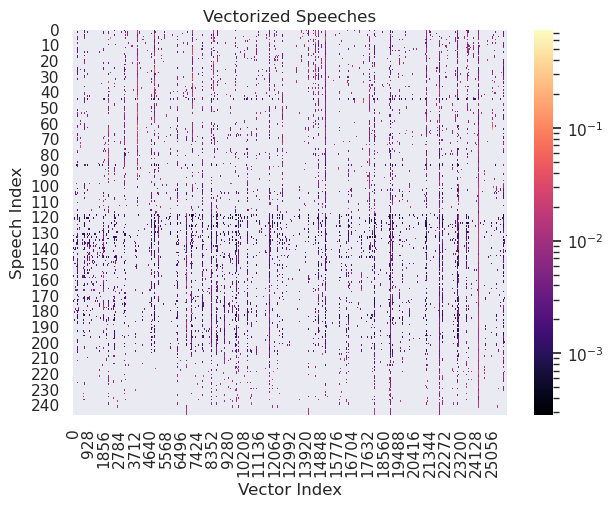

In [125]:
tfidf_dense = tfidf_vectors.toarray()
plt.figure(figsize=(7, 5))
sns.heatmap(
    tfidf_dense,
    cmap="magma",               
    norm=LogNorm()  
)

plt.title("Vectorized Speeches")
plt.xlabel("Vector Index")
plt.ylabel("Speech Index")
plt.show()

In [109]:
word_list = ['year',
 'america',
 'people',
 'american',
 'work',
 'new',
 'job',
 'country',
 'americans',
 'world'] # top ten most common words through whole corpus

In [134]:
# get each word's index number using the .vocabular_ attributed of vectorizer
word_nums = [tfidf_model.vocabulary_[w] for w in word_list]

[25879, 2410, 17259, 2412, 25728, 15972, 13576, 6506, 2416, 25753]

In [129]:
# get their IDF score by using .idf_ at the indices from the previous step
idf_score = [tfidf_model.idf_[i] for i in word_nums]

In [130]:
# get the tf_idf score for the first speech
tf_idf = [tfidf_vectors[0, i] for i in word_nums]

In [131]:
pd.DataFrame({
    "Word": word_list,
    "IDF Score": idf_score,
    "TF-IDF Score": tf_idf
})


,Word,IDF Score,TF-IDF Score
0,year,1.032925,0.022719
1,america,1.272946,0.068439
2,people,1.037118,0.043087
3,american,1.102217,0.045792
4,work,1.162281,0.005681
5,new,1.024591,0.016275
6,job,2.043480,0.009988
7,country,1.008130,0.013550
8,americans,1.713598,0.041877
9,world,1.138750,0.026438
